# Titanic Survival Classification
**CPSC 480 – Classification Project**

## 1. Project Description (Look at the Big Picture)
**Goal:** Predict whether a passenger on the Titanic survived, using information known about the passenger (class, sex, age, family aboard, fare, and port of embarkation). The aim is both to build a model that predicts well on passengers it has not seen and to understand which factors were most associated with survival.

**Type of problem:** Supervised learning, binary classification. The label is `Survived` (1 = survived, 0 = did not survive), and the training data includes the true label for every passenger.

**Features used:** `Pclass` (ticket class), `Sex`, `Age`, `SibSp` (siblings/spouses aboard), `Parch` (parents/children aboard), `Fare`, and `Embarked` (port of embarkation). Identifier and free-text columns (`PassengerId`, `Name`, `Ticket`) were dropped, and `Cabin` was dropped because about 77% of its values are missing.

**Model:** Logistic regression, chosen as a simple, fast, and interpretable baseline whose coefficients show how each feature pushes the prediction toward survival or non-survival.

**Performance measures:** Accuracy (overall share of correct predictions), precision and recall for the "Survived" class, the confusion matrix, and ROC AUC. Accuracy alone can hide weak performance on the smaller class (about 38% of passengers survived), so precision, recall, and AUC are reported as well.

**Steps:**
1. Get the data and inspect its structure and missing values.
2. Visualize the data to find patterns related to survival.
3. Select features and split into 80% training / 20% testing sets (stratified by the label).
4. Build a preprocessing pipeline: impute missing values, scale numeric features, and one-hot encode categorical features.
5. Train a logistic regression model.
6. Evaluate it on the test set with accuracy, precision, recall, a confusion matrix, and an ROC curve.
7. Present the results and conclusions.
8. Describe how the model would be launched, monitored, and maintained.


## 2. Get the Data

In [1]:
# the usual imports: numpy for arrays, pandas for the data, matplotlib for plots
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# read the csv into a dataframe
df = pd.read_csv("titanic.csv")
# quick peek at the first few rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# column names, dtypes, and non-null counts
# any column with fewer than 891 non-nulls has missing values (Age, Cabin, Embarked)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 66.2 KB


In [4]:
# summary stats for the numeric columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# how many missing values in each column
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

**Observations:**
- The dataset has **891 passengers and 12 columns**: 5 integer, 2 float, and 5 text columns.
- **Age** is missing for 177 passengers (about 20%), **Cabin** is missing for 687 (about 77%), and **Embarked** is missing for just 2. All other columns are complete.
- Because Cabin is mostly empty, it was excluded as a feature. Age and Embarked are kept and filled in during preprocessing.
- The overall survival rate is about **38.4%** (mean of `Survived` = 0.384), so there are more passengers who died than survived, but the classes are not extremely imbalanced.
- Most passengers were in **3rd class** (median `Pclass` = 3), and the median age is 28 (range 0.42 to 80).
- **Fare is heavily right-skewed**: the median is about 14.45 but the mean is about 32.20 and the maximum is 512.33, so a few very expensive tickets pull the mean up. The numeric features are on very different scales (e.g., `Fare` vs. `Parch`), which is why scaling is needed.
- Most passengers traveled with few or no relatives aboard (the median for both `SibSp` and `Parch` is 0).


## 3. Discover and Visualize the Data

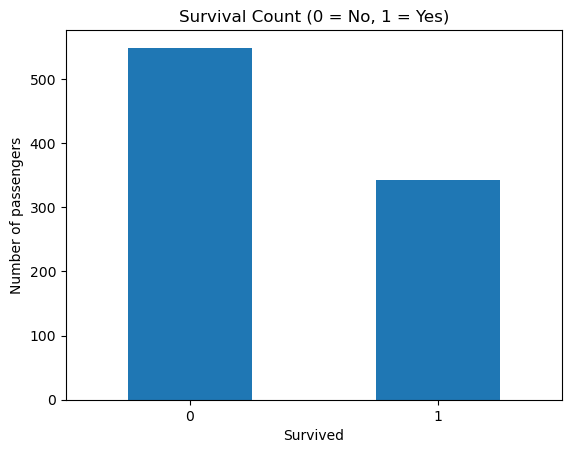

In [6]:
# how many passengers died (0) vs survived (1)
# sort_index keeps the bars in 0, 1 order
df["Survived"].value_counts().sort_index().plot(kind="bar")
plt.title("Survival Count (0 = No, 1 = Yes)")
plt.xlabel("Survived")
plt.ylabel("Number of passengers")
plt.xticks(rotation=0)  # keep the labels flat instead of sideways
plt.show()

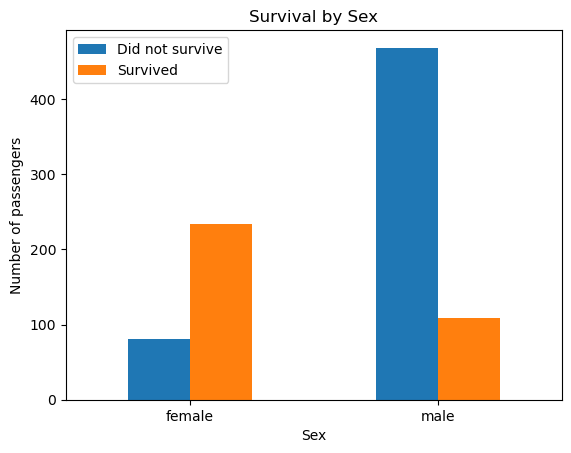

In [7]:
# count survivors vs non-survivors for each sex and plot them side by side
pd.crosstab(df["Sex"], df["Survived"]).plot(kind="bar")
plt.title("Survival by Sex")
plt.ylabel("Number of passengers")
plt.xticks(rotation=0)
plt.legend(["Did not survive", "Survived"])  # crosstab columns are 0 then 1
plt.show()

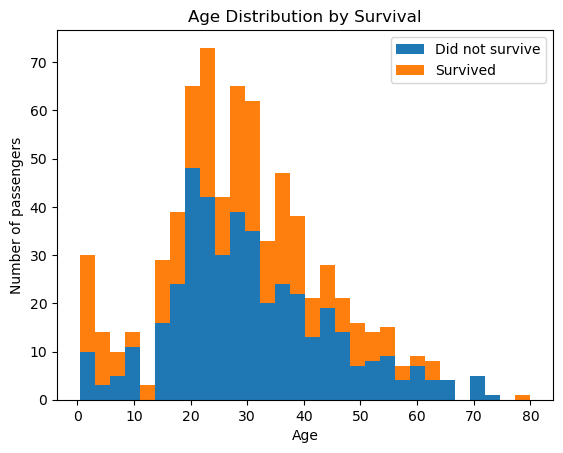

In [9]:
# stacked histogram of age, split into died vs survived
# Age has missing values, so drop those first or the histogram won't work
plt.hist(
    [df[df["Survived"] == 0]["Age"].dropna(), df[df["Survived"] == 1]["Age"].dropna()],
    bins=30, stacked=True, label=["Did not survive", "Survived"]
)
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Number of passengers")
plt.legend()
plt.show()

**Insights:**
- **Sex is the strongest pattern.** Roughly 230 of about 314 women survived (about 74%), while only about 110 of about 577 men survived (about 19%).
- **Age matters, mainly for children.** The youngest passengers (under about 10) had a noticeably higher survival share, while the survival share is lower for most adults, especially those around 20 to 30 and over 60. The relationship is not a simple straight line.
- **In most age groups, more passengers died than survived**, which matches the overall 38% survival rate. The class split is moderate, so accuracy is meaningful but should be read alongside precision and recall.
- These patterns suggest that sex, age, and ticket class should all be useful predictors, and they motivate keeping those features in the model.


## 4. Prepare the Data for Machine Learning

### 4a. Select features and separate the label

In [10]:
# pick the columns the model will use as inputs
# left out PassengerId, Name, and Ticket (just identifiers) and Cabin (mostly missing)
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
X = df[features]
y = df["Survived"]  # what we're trying to predict

### 4b. Split the data into training and testing sets
We split **before** fitting any imputer or scaler so that no information from the test set leaks into preprocessing. We use 80% for training and 20% for testing, and `stratify=y` keeps the survived/not-survived ratio the same in both sets.

In [11]:
from sklearn.model_selection import train_test_split

# 80/20 split
# random_state makes it come out the same every time
# stratify=y keeps the survived/died ratio about the same in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# make sure the sizes look right
print("Training set:", X_train.shape)
print("Testing set: ", X_test.shape)

Training set: (712, 7)
Testing set:  (179, 7)


### 4c. Preprocessing: handle missing values, feature scaling, and encoding

In [12]:
# Build the preprocessing pipeline (impute + scale for numbers, impute + one-hot for categories)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# numbers and text categories get handled differently, so split the columns up
num_cols = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
cat_cols = ["Sex", "Embarked"]

# numbers: fill gaps with the median (Fare is skewed, so median is safer than mean),
# then scale so every column has mean 0 and std 1
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# categories: fill gaps with the most common value, then one-hot encode
# handle_unknown="ignore" means a new category won't crash the encoder later
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# run each pipeline on its own set of columns
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols),
])

In [13]:
# fit on the training data only, so the medians, means, and categories
# come from the training set and nothing leaks in from the test set
X_train_prepared = preprocessor.fit_transform(X_train)

# for the test set just transform, reusing what was learned from training
# (calling fit again here would be data leakage)
X_test_prepared = preprocessor.transform(X_test)

print("Prepared training shape:", X_train_prepared.shape)
print("Prepared testing shape: ", X_test_prepared.shape)

Prepared training shape: (712, 10)
Prepared testing shape:  (179, 10)


In [14]:
# sanity check: the scaled numeric columns should have mean ~0 and std ~1
# the numeric columns come first in the output, hence the slice
scaled_numeric = pd.DataFrame(X_train_prepared[:, :len(num_cols)], columns=num_cols)
scaled_numeric.describe().loc[["mean", "std"]].round(2)

,Pclass,Age,SibSp,Parch,Fare
mean,-0.0,0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0


## 5. Select a Model and Train It.

In [15]:
from sklearn.linear_model import LogisticRegression

# logistic regression as a simple baseline
model = LogisticRegression(random_state=42)

# train on the prepared training data
model.fit(X_train_prepared, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [16]:
from sklearn.metrics import accuracy_score

# predict on both sets so we can compare train vs test accuracy
# if train were much higher than test, that would point to overfitting
y_train_pred = model.predict(X_train_prepared)
y_test_pred = model.predict(X_test_prepared)
print("Training accuracy:", round(accuracy_score(y_train, y_train_pred), 3))
print("Testing accuracy: ", round(accuracy_score(y_test, y_test_pred), 3))

Training accuracy: 0.808
Testing accuracy:  0.804


## 6. Evaluate the Model

In [17]:
from sklearn.metrics import classification_report, precision_score, recall_score

# precision, recall, and f1 for each class on the test set
print(classification_report(y_test, y_test_pred, target_names=["Did not survive", "Survived"]))

# precision: when the model says "survived", how often is it right?
print("Precision (Survived):", round(precision_score(y_test, y_test_pred), 3))
# recall: out of everyone who really survived, how many did it catch?
print("Recall (Survived):   ", round(recall_score(y_test, y_test_pred), 3))

                 precision    recall  f1-score   support

Did not survive       0.81      0.89      0.85       110
       Survived       0.79      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179

Precision (Survived): 0.793
Recall (Survived):    0.667


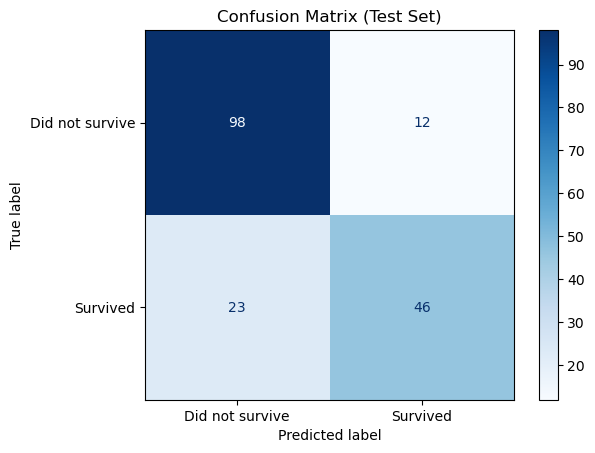

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay

# rows are the actual classes, columns are what the model predicted
# the diagonal is correct predictions, the off-diagonal cells are mistakes
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=["Did not survive", "Survived"],
    cmap="Blues"
)
plt.title("Confusion Matrix (Test Set)")
plt.show()

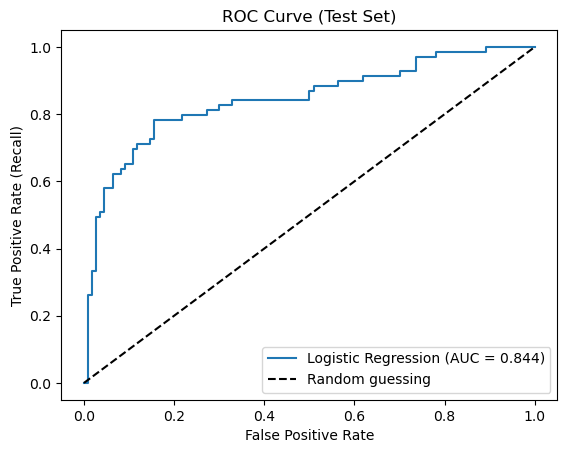

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

# the ROC curve needs probabilities, not just 0/1 predictions
y_scores = model.predict_proba(X_test_prepared)[:, 1]   # probability of survival
fpr, tpr, thresholds = roc_curve(y_test, y_scores)      # one point per threshold
auc = roc_auc_score(y_test, y_scores)                   # 1.0 is perfect, 0.5 is a coin flip

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guessing")  # diagonal = random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve (Test Set)")
plt.legend()
plt.show()

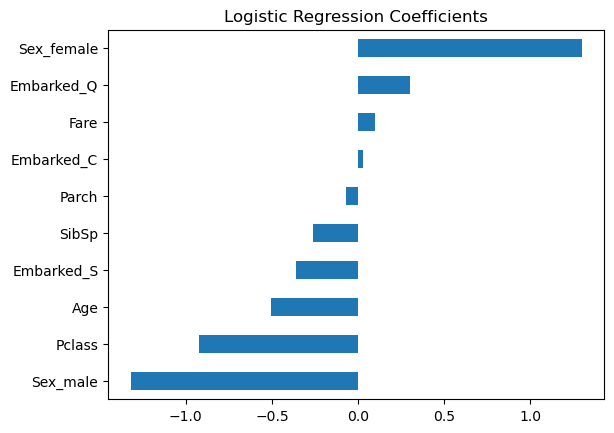

In [20]:
# get the feature names after preprocessing: the numeric ones first,
# then the one-hot columns (Sex_female, Sex_male, Embarked_C, etc.)
feature_names = num_cols + list(preprocessor.named_transformers_["cat"]["onehot"].get_feature_names_out(cat_cols))

# match each coefficient to its feature and sort smallest to largest
# positive = pushes toward survived, negative = pushes toward did not survive
coefs = pd.Series(model.coef_[0], index=feature_names).sort_values()
coefs.plot(kind="barh")
plt.title("Logistic Regression Coefficients")
plt.show()

## 7. Present the Solution / Conclusions
**Results (test set, 179 passengers):**
- **Accuracy:** 0.804 on the test set (0.808 on the training set). The two values are very close, so the model does not appear to be overfitting.
- **Confusion matrix:** 98 true negatives (correctly predicted did not survive), 12 false positives (predicted survived, actually did not), 23 false negatives (predicted did not survive, actually survived), and 46 true positives (correctly predicted survived).
- **Precision (Survived):** 0.793. When the model predicts that a passenger survived, it is right about 79% of the time.
- **Recall (Survived):** 0.667. The model finds about 67% of the passengers who actually survived and misses about a third of them.
- **ROC AUC:** 0.844, well above the 0.5 expected from random guessing, so the model ranks survivors above non-survivors well across thresholds.

**What the model learned:** The coefficients agree with the patterns found in Section 3. Being female is the strongest push toward survival (the `Sex_female` coefficient is about +1.3, and `Sex_male` is the mirror image at about -1.3). Ticket class is the next strongest factor: a higher `Pclass` number (lower class) lowers the chance of survival (about -0.9). Older age (about -0.5), embarking at Southampton, and having more siblings/spouses aboard also lower it slightly. Fare, `Parch`, and the other ports have small coefficients, so they contribute little once sex, class, and age are known. Note that the numeric features were standardized, so their coefficients are comparable in size.

**Limitations and possible improvements:**
- **Recall for survivors is the weak spot** (0.667 vs. 0.89 for non-survivors). The model is more cautious about predicting survival; lowering the decision threshold below 0.5 would trade some precision for higher recall.
- **Small dataset.** With 891 passengers, and only 179 in the test set, a single split gives a noisy estimate. Cross-validation would give a more reliable one.
- **Linear model.** Logistic regression assumes each feature has a straight-line effect and cannot capture interactions on its own (for example, the effect of class may differ for men and women, and children behaved differently from adults). Adding interaction terms or trying tree-based models (random forest, gradient boosting) could improve performance.
- **Missing data.** Age was filled with the median and Embarked with the most common value. Missing Age may not be random, so this adds some bias.
- **Unused information.** Titles in `Name` (Mr., Mrs., Miss, Master), family size, deck from `Cabin`, and ticket groups were not used and could add signal through feature engineering.
- **Historical data.** The model describes who survived one specific event and should not be used to make real-world predictions about people.


## 8. Launch, Monitor, and Maintain

The Titanic data is a fixed historical dataset, so this model would never actually be deployed. The plan below describes what launching, monitoring, and maintaining a model like this would involve if it were put into production.

### 8a. Launch

**What gets deployed:** the preprocessing steps and the model must ship together as one object. If only the model were saved, new data would not be imputed, scaled, or one-hot encoded the same way as the training data, and predictions would be wrong. The code cells below combine them into a single pipeline, save it with `joblib`, and wrap prediction in a function.

**How it would be served:**
- Load the saved pipeline in a small web service (for example, a REST API built with FastAPI or Flask) that accepts passenger details as JSON and returns a survival probability.
- Validate inputs before predicting (e.g., `Sex` must be a known category, `Age` must be a plausible number, `Pclass` must be 1, 2, or 3).
- Store the model with a version number and the scikit-learn version used to train it, because a pickled model may not load correctly under a different version.


In [ ]:
# put the preprocessing and the model into ONE pipeline
# that way raw data goes in and predictions come out, no manual steps in between
import joblib
from sklearn.base import clone

full_pipeline = Pipeline([
    ("preprocessor", clone(preprocessor)),             # same preprocessing as 4c (clone = fresh unfitted copy)
    ("model", LogisticRegression(random_state=42)),    # same model as Section 5
])

# fit on the raw training features, since the pipeline does the imputing/scaling/encoding itself
full_pipeline.fit(X_train, y_train)

# should match the test accuracy from Section 5
print("Pipeline test accuracy:", round(full_pipeline.score(X_test, y_test), 3))

# save it to a file so a web service could load it later
joblib.dump(full_pipeline, "titanic_survival_pipeline_v1.joblib")

In [ ]:
# load the saved pipeline back in and wrap it in a function
# this is the part an API endpoint would call
loaded_pipeline = joblib.load("titanic_survival_pipeline_v1.joblib")

def predict_survival(passenger: dict) -> dict:
    """Return the survival probability and predicted label for one passenger."""
    # basic checks so bad input fails with a clear message
    if passenger.get("Sex") not in ("male", "female"):
        raise ValueError("Sex must be 'male' or 'female'")
    if passenger.get("Pclass") not in (1, 2, 3):
        raise ValueError("Pclass must be 1, 2, or 3")

    # the pipeline expects a dataframe with the same columns used in training
    row = pd.DataFrame([passenger], columns=features)
    prob = loaded_pipeline.predict_proba(row)[0, 1]    # chance of survival
    return {"survival_probability": round(float(prob), 3), "predicted_survived": int(prob >= 0.5)}

# try it on a made-up passenger (use np.nan for any missing value and the imputers fill it in)
predict_survival({"Pclass": 3, "Sex": "male", "Age": 22, "SibSp": 1, "Parch": 0, "Fare": 7.25, "Embarked": "S"})

### 8b. Monitor

| What to watch | Why it matters | Example check |
|---|---|---|
| **Input data drift** | If incoming passengers differ from the training data (e.g., a very different age or fare distribution), the model is working outside what it learned. | Compare the mean, spread, and missing-value rate of each feature against the training set. |
| **Prediction drift** | A sudden shift in the share of predicted survivors can signal a data or model problem. | Track the average predicted probability over time. |
| **Model performance** | This is the true measure of quality, but it needs the real outcomes. | Compare predictions against known outcomes when they become available, and track accuracy, precision, recall, and AUC. Alert if they fall below the test-set values from Section 6. |
| **System health** | The service has to be available and fast. | Monitor errors, latency, and failed input validations. |

The cell below is a small example of a drift check:


In [ ]:
# simple drift check: has the new data moved away from the training data?
# X_test is standing in for "new data that shows up after launch"
def drift_report(train_df, new_df, numeric_cols, threshold=0.5):
    """Flag numeric features whose mean moved more than `threshold` training std devs."""
    rows = []
    for col in numeric_cols:
        train_mean, train_std = train_df[col].mean(), train_df[col].std()
        shift = abs(new_df[col].mean() - train_mean) / train_std   # how far the mean moved, in std devs
        rows.append({
            "feature": col,
            "train_mean": round(train_mean, 2),
            "new_mean": round(new_df[col].mean(), 2),
            "shift_in_std": round(shift, 2),
            "missing_rate_new": round(new_df[col].isnull().mean(), 3),
            "drift_flag": shift > threshold,
        })
    return pd.DataFrame(rows)

drift_report(X_train, X_test, num_cols)

### 8c. Maintain

- **Retrain on a schedule or on a trigger:** retrain periodically with newly collected labeled data, or whenever monitoring shows drift or a drop in performance.
- **Reuse the same pipeline:** retraining should rerun the same split, preprocessing, and evaluation steps in this notebook so results stay comparable.
- **Compare before replacing:** evaluate each new model on the same held-out test set against the current one, and only promote it if it performs better.
- **Keep versions and a rollback path:** save each model version, with the date and data it was trained on, so a bad release can be reverted quickly.
- **Document and review:** record the assumptions and known limitations (see Section 7) and periodically revisit which features are used and whether they should be.
